In [ ]:
!git clone https://github.com/yeonsumia/palmistry.git

Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 15.01 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.


In [ ]:
import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [ ]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 30.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
import mediapipe as mp

print("Version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

Version: 0.10.14
Has solutions: True


In [ ]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os
from PIL import Image

print("MediaPipe version:", mp.__version__)

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("MediaPipe imported successfully")

MediaPipe version: 0.10.14
MediaPipe imported successfully


In [ ]:
!unzip -q "/content/drive/MyDrive/Ai Palmistry project/archive.zip" -d "/content/dataset"

In [ ]:
!ls "/content/drive/MyDrive/Ai Palmistry project/palmistry"

classification	data	LICENSE      README.md	results2  whitening.ipynb
code		detect	__pycache__  results	warp


In [ ]:
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.4 MB/s eta 0:00:00


In [ ]:
!python code/read_palm.py --help

2026-07-28 10:45:39.086448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785235539.124920    8153 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785235539.132284    8153 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
usage: read_palm.py [-h] --input INPUT

options:
  -h, --help     show this help message and exit
  --input INPUT  the path to the input


In [ ]:
import glob

image_files = (
    glob.glob("/content/dataset/**/*.jpg", recursive=True) +
    glob.glob("/content/dataset/**/*.jpeg", recursive=True) +
    glob.glob("/content/dataset/**/*.png", recursive=True)
)

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 11076
['/content/dataset/Hands/Hands/Hand_0003820.jpg', '/content/dataset/Hands/Hands/Hand_0005685.jpg', '/content/dataset/Hands/Hands/Hand_0003147.jpg', '/content/dataset/Hands/Hands/Hand_0000795.jpg', '/content/dataset/Hands/Hands/Hand_0008407.jpg']


In [ ]:
test_image = image_files[0]

print(test_image)

/content/dataset/Hands/Hands/Hand_0003820.jpg


In [ ]:
process = subprocess.run(
    [
        "python",
        "code/read_palm.py",
        "--input",
        test_image
    ],
    cwd="/content/drive/MyDrive/Ai Palmistry project/palmistry",
    capture_output=True,
    text=True
)

print("Return code:", process.returncode)
print(process.stdout)
print(process.stderr)

Return code: 0

2026-07-28 10:59:10.492744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785236350.533331   11633 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785236350.545418   11633 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785236356.668259   11703 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785236356.699058   11703 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/

In [ ]:
!ls "/content/drive/MyDrive/Ai Palmistry project/palmistry/results"

out_1-1.jpg	palm_without_background.jpg  warped_palm_clean_mini.jpg
out_1-2.jpg	result.jpg		     warped_palm.jpg
out_1-3.jpg	warped_1-2.jpg		     warped_palm_mini.jpg
palm_lines.png	warped_palm_clean.jpg


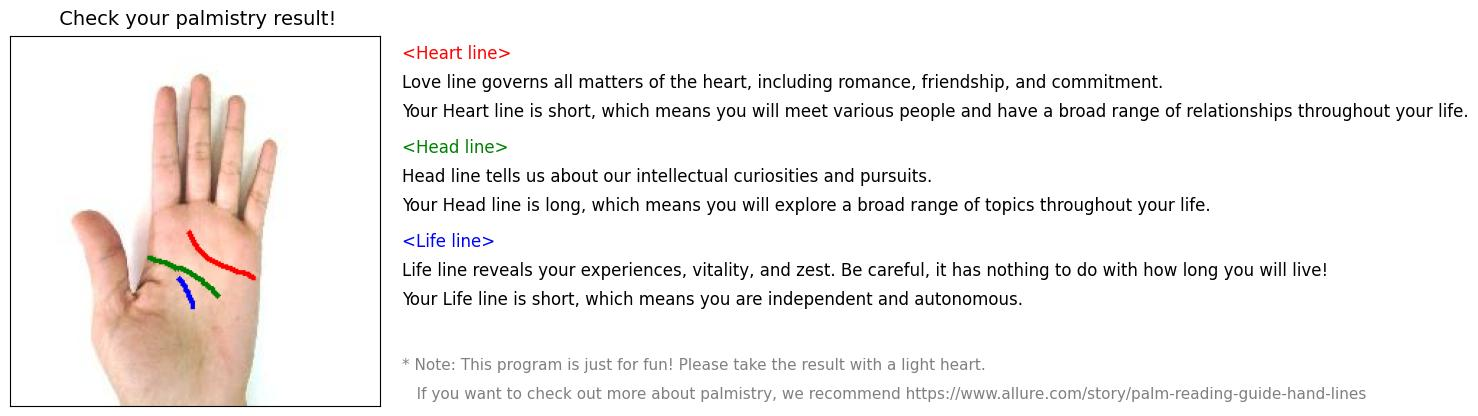

In [ ]:
from IPython.display import display
from PIL import Image

img = Image.open(
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/result.jpg"
)

display(img)

In [ ]:
import glob

image_files = glob.glob("/content/dataset/Hands/Hands/*.jpg")

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 11076
['/content/dataset/Hands/Hands/Hand_0003820.jpg', '/content/dataset/Hands/Hands/Hand_0005685.jpg', '/content/dataset/Hands/Hands/Hand_0003147.jpg', '/content/dataset/Hands/Hands/Hand_0000795.jpg', '/content/dataset/Hands/Hands/Hand_0008407.jpg']


In [ ]:
import os

repo = "/content/drive/MyDrive/Ai Palmistry project/palmistry"

os.makedirs(
    repo + "/input",
    exist_ok=True
)

print("input folder ready")

input folder ready


In [ ]:
import glob
import shutil
import os
from tqdm import tqdm

source_images = glob.glob("/content/dataset/Hands/Hands/*.jpg")

input_folder = "/content/drive/MyDrive/Ai Palmistry project/palmistry/input"

for img in tqdm(source_images):
    shutil.copy(
        img,
        input_folder
    )

print("Copied:", len(source_images))

100%|██████████| 11076/11076 [02:16<00:00, 81.41it/s]

Copied: 11076


In [ ]:
import glob

images = glob.glob("/content/dataset/Hands/Hands/*.jpg")

test_image = images[0]

print(test_image)

/content/dataset/Hands/Hands/Hand_0003820.jpg


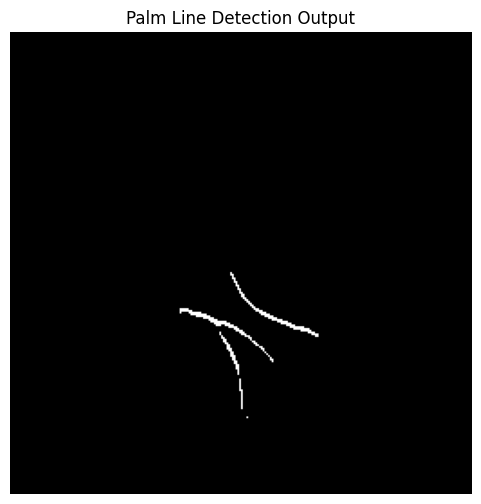

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

result_path = "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_lines.png"

img = Image.open(result_path)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Palm Line Detection Output")
plt.axis("off")
plt.show()